# Taller: Modelos de Regresión - Predicción de Precios de Autos Usados
 
En este notebook encontrarán la estructura base para construir un modelo capaz de estimar el precio de venta de un vehículo. Sigan las instrucciones en los comentarios para completar el desafío.

In [324]:
# Paso 0: Importación de librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
# TIP: No olviden importar los tres regresores que van a evaluar, además de las funciones
# para calcular el R2 (r2_score) y el Error Cuadrático Medio (mean_squared_error) si lo requieren.

## 1. Carga de Datos y Análisis Exploratorio Inicial

Los datos para realizar el ejercicio se encuentran aqui: [Car Price Prediction Dataset](https://www.kaggle.com/datasets/sukhmandeepsinghbrar/car-price-prediction-dataset)

In [325]:
# Paso 1: Usa pandas para cargar el dataset descargado de Kaggle
base_data = pd.read_csv (r"C:\Users\Usuario\Downloads\cardekho.csv")


In [326]:
# TIP 1: Exploren las primeras filas con .head(), verifiquen los tipos de datos con .info()
# y revisen si existen valores nulos antes de avanzar.
base_data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [327]:
base_data.info()  

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   str    
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   str    
 5   seller_type         8128 non-null   str    
 6   transmission        8128 non-null   str    
 7   owner               8128 non-null   str    
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   str    
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), str(6)
memory usage: 762.1 KB


In [328]:
## Como hay valores nulos, prefiero eliminar los valores para que no me afecte los modelos.
base_data = base_data.dropna()

In [329]:
base_data.info()

<class 'pandas.DataFrame'>
Index: 7907 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                7907 non-null   str    
 1   year                7907 non-null   int64  
 2   selling_price       7907 non-null   int64  
 3   km_driven           7907 non-null   int64  
 4   fuel                7907 non-null   str    
 5   seller_type         7907 non-null   str    
 6   transmission        7907 non-null   str    
 7   owner               7907 non-null   str    
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7907 non-null   str    
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), str(6)
memory usage: 803.1 KB


In [330]:
# TIP 2: Realicen un análisis estadístico descriptivo preliminar empleando .describe().
# Observen las escalas y rangos de las variables numéricas.
base_data.describe()


,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats
count,7907.000000,7.907000e+03,7.907000e+03,7907.000000,7907.000000,7907.000000
mean,2013.982168,6.497417e+05,6.919256e+04,19.418783,1458.625016,5.416719
std,3.866650,8.135565e+05,5.678976e+04,4.037145,503.916303,0.959588
min,1994.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,2.000000
25%,2012.000000,2.700000e+05,3.500000e+04,16.780000,1197.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,5.000000
75%,2017.000000,6.900000e+05,9.575000e+04,22.320000,1582.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,14.000000


## 2. Preprocesamiento de Datos e Ingeniería de Características
En esta sección deben transformar las variables categóricas en formatos numéricos aptos para los modelos.

In [331]:
base_data['owner'].value_counts()

owner
First Owner             5215
Second Owner            2017
Third Owner              510
Fourth & Above Owner     160
Test Drive Car             5
Name: count, dtype: int64

In [332]:
# Paso 2: Limpieza y transformación de datos

# TIP 1 (One-Hot Encoding): Columnas sin un orden específico como 'fuel' (Diesel, Petrol, etc.), 
# 'seller_type' (Individual, Dealer) y 'transmission' (Manual, Automatic) deben transformarse 
# usando pd.get_dummies() o OneHotEncoder().
base_data = pd.get_dummies(base_data, columns=['fuel', 'seller_type', 'transmission'], drop_first=True, dtype=int)

# TIP 2 (Ordinal Encoding): La columna 'owner' (First Owner, Second Owner, etc.) tiene 
# una jerarquía clara. Un auto con un solo dueño previo suele valer más. Mapeen estos 
# valores a números enteros (ej. First Owner = 1, Second Owner = 2, etc.).
owners_order = {
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4,
    'Test Drive Car': 0
}
base_data['owner'] = base_data['owner'].map(owners_order)
# TIP 3: La columna 'name' tiene demasiados valores únicos (alta cardinalidad). 
# Para este ejercicio no es necesario incluirla como variable predictora. Pueden eliminarla
base_data = base_data.drop(columns=['name'])
# TIP 4: Si existen columnas que deberian ser númericas pero tienen texto (ej. "23.4 kmpl" o "1248 CC"), 
# utilicen métodos de strings en pandas (.str.replace, .str.split) para extraer solo el número y luego conviertan la columna usando astype(float).
## Tocó colocar el .astype(str) porque me estaba arrojando error porque me habia quedado mal pero ya había cambiado a float,
#  así q me toco cambiarlo a str para pasarlo a float y me ejecutara bien.
base_data['mileage(km/ltr/kg)'] = base_data['mileage(km/ltr/kg)'].astype(str).str.split().str[0].astype(float)
base_data['engine'] = base_data['engine'].astype(str).str.split().str[0].astype(float)
base_data['max_power'] = base_data['max_power'].astype(str).str.split().str[0].astype(float)


### Escalado de los datos
Algunos modelos requeriran escalar los datos previamente, por ende es necesario hacer esto previo al entrenamiento

In [333]:
# Escalado de Variables y Definición de X e y
# TIP: Definan su matriz X y su vector y (columna objetivo: 'selling_price').
y = base_data['selling_price'] #columna objetv.
X = base_data.drop(columns=['selling_price'])

# Como 'km_driven' tiene valores muy grandes, apliquen un StandardScaler a X.
scale = StandardScaler() 
X_scale = scale.fit_transform(X)

## 3. División del Dataset
Separación de los datos en conjuntos de entrenamiento y prueba.

In [334]:
# Paso 3: Train/Test Split
# TIP: Utilicen train_test_split de sklearn. Configuren un test_size adecuado (ej. 15% o 20%)
# y un random_state fijo para que sus resultados sean replicables.
X_train, X_test, y_train, y_test = train_test_split(
    X_scale,          
    y,                 
    test_size=0.20,    # 20% 
    random_state=48  
)

## 4. Entrenamiento de Modelos
 
Entrenen tres algoritmos de regresión distintos para comparar cuál captura mejor la relación entre las características y el precio.

### Random Forest

Métricas
MSE: 46737394057.187
RMSE: 216188.330
R²: 0.923


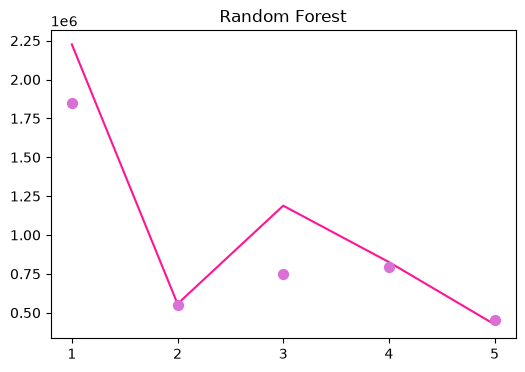

In [335]:
## Paso 4: Entrenamiento y evaluación de modelos

# Modelo 1: Instanciar, entrenar con datos de train y predecir con datos de test (RANDOM FOREST)

model_rf = RandomForestRegressor(n_estimators=100, random_state=48)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

#metricas
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Métricas")
print(f"MSE: {mse_rf:.3f}")
print(f"RMSE: {rmse_rf:.3f}")
print(f"R²: {r2_rf:.3f}")

# Grafica
plt.figure(figsize=(6, 4))
x_axis = np.arange(1, 6)
plt.scatter(
    x_axis, y_test[:5], color='orchid', s=50, zorder=3, label='Valores Reales'
)
plt.plot(
    x_axis,
    y_pred_rf[:5],
    color='deeppink',
    linewidth=1.5,
    zorder=2,
    label='Predicción RF',
)
plt.title('Random Forest', fontsize=12)
plt.xticks(x_axis)
plt.show()

In [336]:
## Revisar nuevamente los null ya que no me corre el modelo lineal
print(base_data.isna().sum())

year                            0
selling_price                   0
km_driven                       0
owner                           0
mileage(km/ltr/kg)              0
engine                          0
max_power                       1
seats                           0
fuel_Diesel                     0
fuel_LPG                        0
fuel_Petrol                     0
seller_type_Individual          0
seller_type_Trustmark Dealer    0
transmission_Manual             0
dtype: int64


In [337]:
## Volver para eliminar el null de max power
base_data = base_data.dropna()

In [338]:
## Confirmarr
print(base_data.isna().sum())

year                            0
selling_price                   0
km_driven                       0
owner                           0
mileage(km/ltr/kg)              0
engine                          0
max_power                       0
seats                           0
fuel_Diesel                     0
fuel_LPG                        0
fuel_Petrol                     0
seller_type_Individual          0
seller_type_Trustmark Dealer    0
transmission_Manual             0
dtype: int64


### Regresión lineal

Métricas
MSE: 191126594513.955
RMSE: 437180.277
R²: 0.660


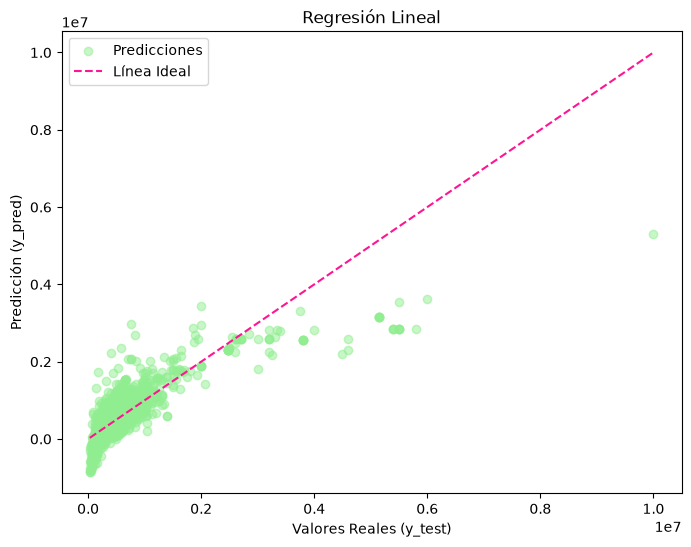

In [339]:
#Volver a entrenar y definir ya que por el null no pude modelar sin entrenar nuevamente
y = base_data['selling_price']
X = base_data.drop(columns=['selling_price'])

scale = StandardScaler()
X_scale = scale.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scale, y, test_size=0.20, random_state=48
)

# Modelo 2: Instanciar, entrenar con datos de train y predecir con datos de test (Regresión lineal)
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

#metricas
mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred)

print("Métricas")
print(f"MSE: {mse_lr:.3f}")
print(f"RMSE: {rmse_lr:.3f}")
print(f"R²: {r2_lr:.3f}")

#Gráfica 
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='lightgreen', label='Predicciones')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='deeppink', linestyle='--', label='Línea Ideal')

plt.xlabel('Valores Reales (y_test)')
plt.ylabel('Predicción (y_pred)')
plt.title('Regresión Lineal')
plt.legend()
plt.show()

### Árbol de decisión

métricas
MSE: 61270774239.488
RMSE: 247529.340
R²: 0.891


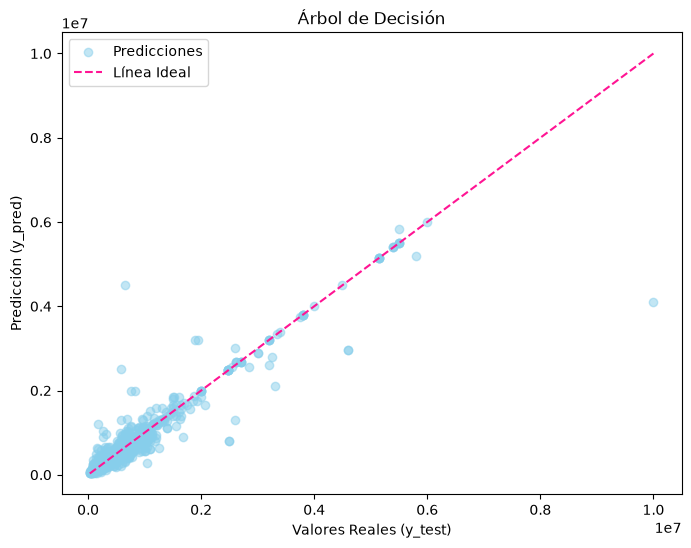

In [340]:
# Modelo 3: Instanciar, entrenar con datos de train y predecir con datos de test (ÁRBOL DE DECISIÓN)

model_dt = DecisionTreeRegressor(random_state=48)
model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

# Métricas
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("métricas")
print(f"MSE: {mse_dt:.3f}")
print(f"RMSE: {rmse_dt:.3f}")
print(f"R²: {r2_dt:.3f}")

# Gráfica
plt.figure(figsize=(8, 6))
plt.scatter(
    y_test, y_pred_dt, alpha=0.5, color='skyblue', label='Predicciones'
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='deeppink',
    linestyle='--',
    label='Línea Ideal',
)

plt.xlabel('Valores Reales (y_test)')
plt.ylabel('Predicción (y_pred)')
plt.title('Árbol de Decisión')
plt.legend()
plt.show()

## 5. Evaluación y Comparación de Resultados
Generen las métricas y las gráficas solicitadas para contrastar el rendimiento de los tres modelos.

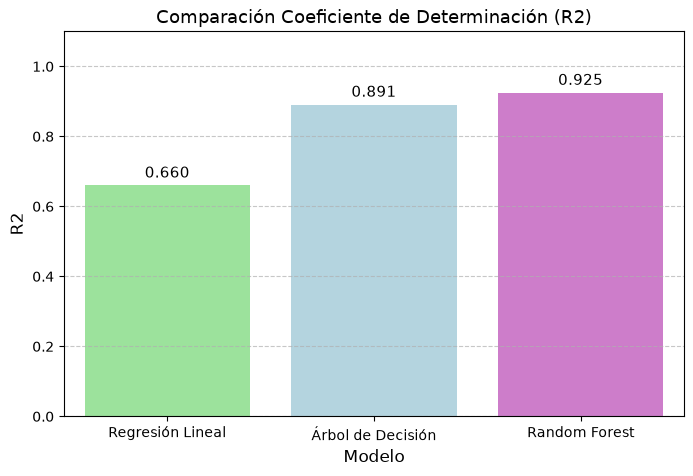

In [341]:
# Cálculo y comparación del coeficiente de determinación (R2 Score)
# TIP: Calculen el R2 para las predicciones de los tres modelos. 
# Generen un gráfico de barras (sns.barplot) que compare visualmente qué modelo obtuvo el puntaje más alto.
y_pred_lr = model.predict(X_test)  # Modelo Regresión Lineal
y_pred_dt = model_dt.predict(X_test)  # Modelo Árbol de Decisión
y_pred_rf = model_rf.predict(X_test)  # Modelo Random Forest

# R2
r2_lr = r2_score(y_test, y_pred_lr)
r2_dt = r2_score(y_test, y_pred_dt)
r2_rf = r2_score(y_test, y_pred_rf)

df_r2 = pd.DataFrame(
    {
        'Modelo': ['Regresión Lineal', 'Árbol de Decisión', 'Random Forest'],
        'R2_Score': [r2_lr, r2_dt, r2_rf],
    }
)

colores_modelos = {
    'Regresión Lineal': 'lightgreen', 
    'Árbol de Decisión': 'lightblue', 
    'Random Forest': 'orchid',
}

# Gráfico 
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=df_r2, x='Modelo', y='R2_Score', palette=colores_modelos, hue='Modelo'
)

for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(
            f'{height:.3f}',
            (p.get_x() + p.get_width() / 2.0, height),
            ha='center',
            va='bottom',
            fontsize=11,
            xytext=(0, 3),
            textcoords='offset points',
        )

plt.title(
    'Comparación Coeficiente de Determinación (R2)', fontsize=13
)
plt.xlabel('Modelo', fontsize=12)
plt.ylabel('R2', fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

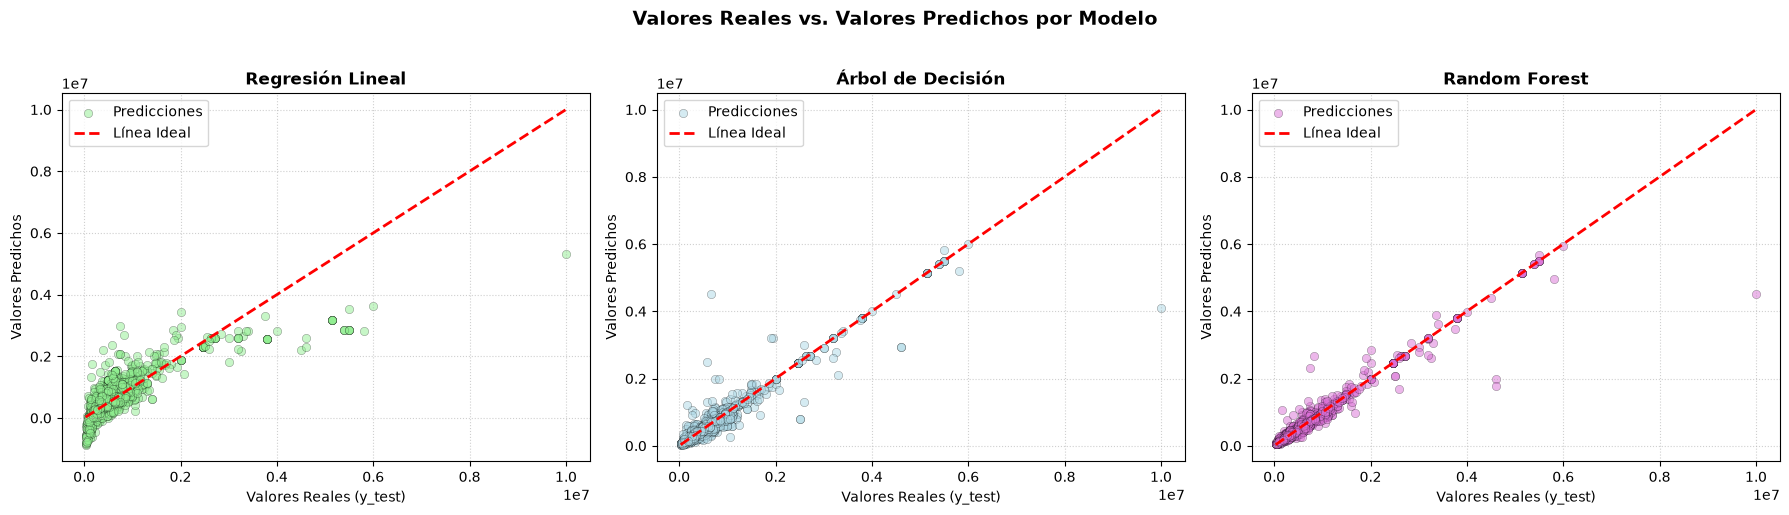

In [342]:
# Gráfica de Valores Reales vs. Valores Predichos
# TIP: Creen un gráfico de dispersión (plt.scatter) para cada modelo.
# - Eje X: y_test (Valores reales)
# - Eje Y: Predicciones del modelo
# Dibujen una línea diagonal roja de referencia. Los puntos más cercanos a la línea representan predicciones más exactas.


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modelos_data = [
    ('Regresión Lineal', y_pred, 'lightgreen'),
    ('Árbol de Decisión', y_pred_dt, 'lightblue'),
    ('Random Forest', y_pred_rf, 'orchid'),
]

min_val = float(np.min(y_test))
max_val = float(np.max(y_test))

# Grafico
for ax, (nombre_modelo, predicciones, color) in zip(axes, modelos_data):
    # Gráfico de dispersión
    ax.scatter(
        y_test,
        predicciones,
        alpha=0.5,
        color=color,
        edgecolors='k',
        linewidth=0.3,
        label='Predicciones',
    )
    
    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        color='red',
        linestyle='--',
        linewidth=2,
        label='Línea Ideal',
    )

    ax.set_title(nombre_modelo, fontsize=12, fontweight='bold')
    ax.set_xlabel('Valores Reales (y_test)', fontsize=10)
    ax.set_ylabel('Valores Predichos', fontsize=10)
    ax.legend(loc='upper left')
    ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle(
    'Valores Reales vs. Valores Predichos por Modelo',
    fontsize=14,
    fontweight='bold',
    y=1.02,
)
plt.tight_layout()
plt.show()